In [46]:
import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.svm import SVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

In [47]:
mw_fil = "../data/mw_gcs.csv"
df = pd.read_csv(mw_fil)
df

,Cluster,RA,DEC,R_Sun,DRSun,R_GC,DRGC,N_RV,N_PM,Mass,...,U,Delta_U,V,Delta_V.1,W,Delta_W,R_Per,Delta_R_per,R_Apo,Delta_R_Apo
0,NGC_104,6.02379,-72.08131,4.52,0.03,7.52,0.01,7177,27460,853000,...,77.52,0.17,170.83,0.17,46.02,0.17,5.47,0.01,7.51,0.00
1,NGC_288,13.18850,-26.58261,8.99,0.09,12.21,0.06,549,2637,96200,...,4.20,0.15,-48.34,0.16,50.29,0.13,1.93,0.10,12.34,0.07
2,NGC_362,15.80942,-70.84878,8.83,0.10,9.62,0.06,2342,4286,252000,...,93.45,0.36,-98.32,0.33,-67.93,0.32,0.73,0.06,11.84,0.13
3,Whiting_1,30.73750,-3.25278,30.59,1.17,35.15,1.11,3,0,1370,...,-246.96,6.29,32.88,6.60,-7.97,3.57,35.15,1.12,61.94,4.86
4,NGC_1261,48.06754,-55.21622,16.40,0.19,18.28,0.17,345,3179,172000,...,-78.82,0.70,57.52,0.57,68.81,0.46,1.65,0.06,21.08,0.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,NGC_7089,323.36258,-0.82325,11.69,0.11,10.54,0.08,3931,5331,624000,...,73.27,0.47,146.63,0.42,-173.80,0.45,0.88,0.06,18.74,0.22
163,NGC_7099,325.09213,-23.17986,8.46,0.09,7.36,0.04,2902,2021,121000,...,1.80,0.27,-80.48,0.29,107.84,0.25,1.51,0.01,8.56,0.08
164,Pal_12,326.66180,-21.25261,18.49,0.30,15.28,0.26,24,0,6190,...,-327.57,0.92,18.08,0.96,109.51,0.77,15.30,0.27,51.25,3.55
165,Pal_13,346.68519,12.77154,23.48,0.40,24.57,0.36,20,0,2780,...,161.51,4.18,216.80,2.57,-77.87,2.82,6.91,0.34,58.24,1.76


In [48]:
MW_pot = "../.venv312/lib/python3.12/site-packages/agama/data/MWPotential2014.ini"
pot_nbody = agama.Potential(MW_pot)

posvel = np.column_stack((df["X"], df["Y"], df["Z"], df["U"], df["V"], df["W"]))
result = agama.orbit(potential=pot_nbody, ic=posvel, time=10 * pot_nbody.Tcirc(posvel), trajsize=1000)

167 orbits complete (6423 orbits/s)


In [49]:
period = np.array([np.nan] * len(result))

for i in range(len(result)):
    result_i = result[i]

    t_i_agama = result_i[0]
    t_i_myr = t_i_agama * units["time"]  # Myr
    orb_i = result_i[1]

    if np.isnan(posvel[i]).any():
        continue

    r_i = np.linalg.norm(orb_i[:, 0:3], axis=1)

    peaks, _ = find_peaks(r_i)
    t_orb_i = np.mean(np.diff(t_i_myr[peaks]))

    period[i] = t_orb_i

In [50]:
df["t_Myr"] = period
df["t_Gyr"] = period / 1000
df

,Cluster,RA,DEC,R_Sun,DRSun,R_GC,DRGC,N_RV,N_PM,Mass,...,V,Delta_V.1,W,Delta_W,R_Per,Delta_R_per,R_Apo,Delta_R_Apo,t_Myr,t_Gyr
0,NGC_104,6.02379,-72.08131,4.52,0.03,7.52,0.01,7177,27460,853000,...,170.83,0.17,46.02,0.17,5.47,0.01,7.51,0.00,147.743681,0.147744
1,NGC_288,13.18850,-26.58261,8.99,0.09,12.21,0.06,549,2637,96200,...,-48.34,0.16,50.29,0.13,1.93,0.10,12.34,0.07,165.352491,0.165352
2,NGC_362,15.80942,-70.84878,8.83,0.10,9.62,0.06,2342,4286,252000,...,-98.32,0.33,-67.93,0.32,0.73,0.06,11.84,0.13,160.301505,0.160302
3,Whiting_1,30.73750,-3.25278,30.59,1.17,35.15,1.11,3,0,1370,...,32.88,6.60,-7.97,3.57,35.15,1.12,61.94,4.86,1637.860117,1.637860
4,NGC_1261,48.06754,-55.21622,16.40,0.19,18.28,0.17,345,3179,172000,...,57.52,0.57,68.81,0.46,1.65,0.06,21.08,0.23,285.175027,0.285175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,NGC_7089,323.36258,-0.82325,11.69,0.11,10.54,0.08,3931,5331,624000,...,146.63,0.42,-173.80,0.45,0.88,0.06,18.74,0.22,283.017784,0.283018
163,NGC_7099,325.09213,-23.17986,8.46,0.09,7.36,0.04,2902,2021,121000,...,-80.48,0.29,107.84,0.25,1.51,0.01,8.56,0.08,118.560008,0.118560
164,Pal_12,326.66180,-21.25261,18.49,0.30,15.28,0.26,24,0,6190,...,18.08,0.96,109.51,0.77,15.30,0.27,51.25,3.55,1561.989202,1.561989
165,Pal_13,346.68519,12.77154,23.48,0.40,24.57,0.36,20,0,2780,...,216.80,2.57,-77.87,2.82,6.91,0.34,58.24,1.76,1327.653024,1.327653


Text(0, 0.5, 'Orbital Period at z=0')

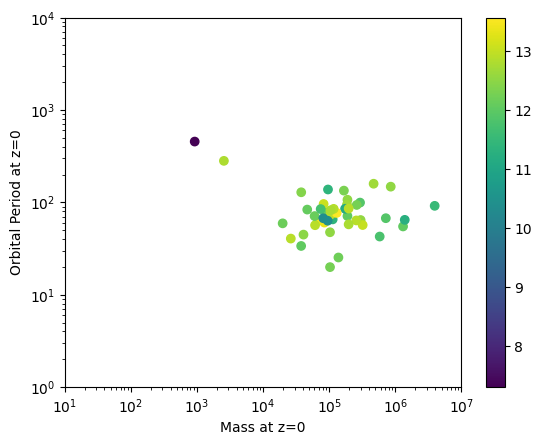

In [51]:
in_situ_msk = df["origin"] == "in_situ"

x = df["Mass"][in_situ_msk]
y = df["t_Myr"][in_situ_msk]
c = df["age"][in_situ_msk]

# plt.figure(figsize=(6, 6))
plt.scatter(x, y, c=c)
plt.colorbar()
plt.xscale("log")
plt.yscale("log")

# plt.xlim([10**1, 10**7])
# plt.ylim([10**0, 10**4])

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

plt.xlabel("Mass at z=0")
plt.ylabel("Orbital Period at z=0")

Propagate detroyed cluster particles in the simulation at z=0 and make this plot. Colour by age destroyed. Trend?

Select orbital period bin and then can plot particles by age at time of death vs mass at formation. Do I include survivng clusters?

In [52]:
def lower_envelope(x, m, x_b, y_b):
    return np.where(x < x_b, m * (x - x_b) + y_b, y_b)


def kde_threshold(Z, fraction):
    """Return KDE level that encloses fraction of total probability."""
    sorted_Z = np.sort(Z.ravel())[::-1]  # descending
    cumsum = np.cumsum(sorted_Z)
    cumsum /= cumsum[-1]  # normalize
    # Find the smallest Z value where cumulative sum >= fraction
    level = sorted_Z[np.searchsorted(cumsum, fraction)]
    return level

In [54]:
r_lim = 3
xyz = np.array([r_lim, r_lim * 0, r_lim * 0])
vy = np.sqrt(-r_lim * pot_nbody.force(xyz)[0])
vxyz = np.array([0, vy, 0])
posvel = np.concatenate((xyz, vxyz))
t_3kpc = pot_nbody.Tcirc(posvel) * units["time"]

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_22528/796641425.py:23: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  contour_path = cont.collections[0].get_paths()[0]


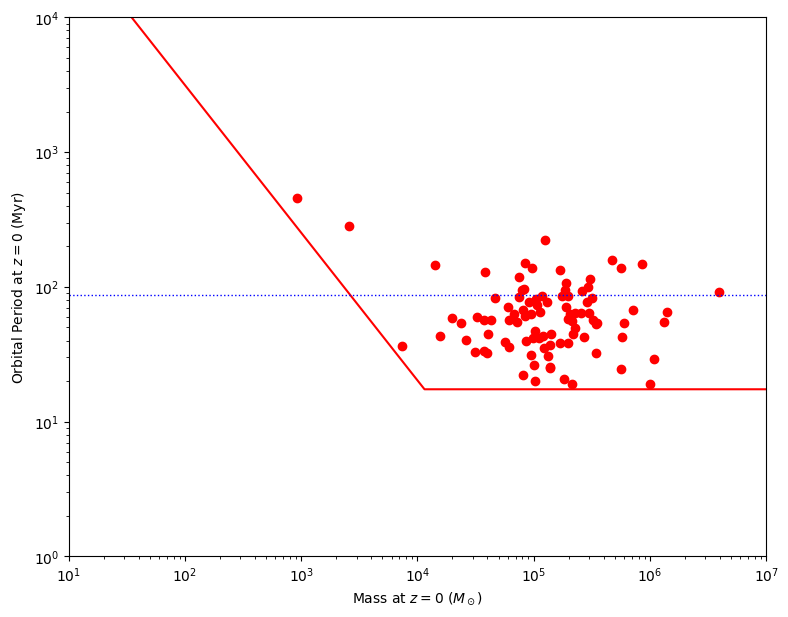

In [56]:
in_situ_msk = df["origin"] == "in_situ"

x = df["Mass"][in_situ_msk]
y = df["t_Myr"][in_situ_msk]

fraction = 0.98

xlog = np.log10(x)
ylog = np.log10(y)

xy = np.vstack([xlog, ylog])
kde = gaussian_kde(xy)
xmin, xmax = 1, 7
ymin, ymax = 1, 3

X, Y = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

level = kde_threshold(Z, fraction)
cont = plt.contour(X, Y, Z, levels=[level], colors="orange")
plt.close()

contour_path = cont.collections[0].get_paths()[0]
vertices = contour_path.vertices
x_contour, y_contour = vertices[:, 0], vertices[:, 1]

# --- Keep only the "lower" part of the contour ---
# We'll bin x values and take the minimum y in each bin
bins = np.linspace(x_contour.min(), x_contour.max(), 100)
x_bin_centers = 0.5 * (bins[:-1] + bins[1:])
y_lower = []
x_lower = []

for i in range(len(bins) - 1):
    mask = (x_contour >= bins[i]) & (x_contour < bins[i + 1])
    if np.any(mask):
        x_lower.append(x_bin_centers[i])
        y_lower.append(np.min(y_contour[mask]))

x_lower = np.array(x_lower)
y_lower = np.array(y_lower)

# --- Fit lower-envelope function ---
p0 = [-1, 4, 1]  # initial guess: slope, x_b, y_b
params, cov = curve_fit(lower_envelope, x_lower, y_lower, p0=p0)

xfit = np.logspace(1, 7)
xfitlog = np.log10(xfit)
yfitlog = lower_envelope(xfitlog, *params)
yfit = 10**yfitlog

plt.figure(figsize=(9, 7))

plt.scatter(x, y, c="r")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"Mass at $z=0$ ($M_\odot$)")
plt.ylabel(r"Orbital Period at $z=0$ (Myr)")

plt.xlim(10**1, 10**7)
plt.ylim(10**0, 10**4)

plt.plot(xfit, yfit, c="r")

plt.plot([10**1, 10**7], [t_3kpc, t_3kpc], c="b", ls=":", lw=1)